In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import random
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

#custom imports
from mpp.ml.datasets.fabricad import Fabricad

In [8]:
#set random seed for reproducibility
random.seed(42)
# Set the random seed for PyTorch
torch.manual_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

#checkpoint_path = Path("/home/michelkruse/repos/cadtoseq/outputs/cadtoseq/2025-05-06-09:50:25_None/lightning_logs/version_0/checkpoints/epoch=943-val_loss=0.4672.ckpt")
checkpoint_path = Path("/home/michelkruse/repos/cadtoseq/src/cadtoseq/ml/models/checkpoints/best_model/manuf_step_decoder-epoch=80-val_loss=0.1774.ckpt")

model = ARMSTM.load_from_checkpoint(checkpoint_path=checkpoint_path.as_posix())
model = model.to("cuda")
model.eval();

In [9]:
def collate_fn(batch):
    vecsets, plans = zip(*batch)
    vecsets = torch.stack(vecsets)

    max_len = 10
    padded_plans = torch.full((len(plans), max_len), VOCAB["PAD"], dtype=torch.long)

    for i, plan in enumerate(plans):
        padded_plans[i, :plan.size(0)] = plan

    return vecsets, padded_plans

In [10]:
dataset = Fabricad(mode="test")
test_loader = torch.utils.data.DataLoader(dataset, batch_size=58, shuffle=True, collate_fn=collate_fn)
#v, p = next(iter(test_loader))

2025-08-11 10:17:04     INFO - Dataset initialized with 10050 samples for test mode.


In [11]:
all_generated_sequences = []
all_ground_truth_sequences = []

for batch in test_loader:
    vec_sets, seq = batch
  
    generated_sequences = model.generate(vec_sets, device=device)

    diff = 10 - generated_sequences.shape[-1]

    fill_tensor = torch.full((generated_sequences.shape[0], diff), VOCAB["PAD"], dtype=torch.long).to(device="cuda")

    # Concatenate the generated sequences with the fill tensor
    padded_generated_sequences = torch.cat((generated_sequences, fill_tensor), dim=1)
    all_generated_sequences.append(padded_generated_sequences)
    all_ground_truth_sequences.append(seq)



In [12]:
result = (padded_generated_sequences == seq.to(device)).all(dim=1) 

In [13]:
import torch
import numpy as np

class SequenceComparator:
    def __init__(self, vocab, max_shift=1, ignore_after_stop=True):
        """
        Args:
            stop_token (int): ID des STOP-Tokens
            max_shift (int): Maximal erlaubte Verschiebung bei shifted_accuracy
            ignore_after_stop (bool): Ob nach erstem STOP Token abgeschnitten wird
        """
        self.stop_token = vocab["STOP"]
        self.pad_token = vocab["PAD"]
        self.token_names = {v: k for k, v in vocab.items()}
        self.max_shift = max_shift
        self.ignore_after_stop = ignore_after_stop

    def _create_mask(self, seq):
        """Erstellt Maske für gültige Tokens (kein Padding und optional bis STOP)."""
        valid = seq != self.stop_token

        if self.ignore_after_stop:
            masks = []
            for s in seq:
                stop_positions = (s == self.stop_token).nonzero(as_tuple=True)
                if len(stop_positions[0]) > 0:
                    stop_idx = stop_positions[0][0]
                    mask = torch.zeros_like(s, dtype=torch.bool)
                    mask[:stop_idx] = True
                else:
                    mask = torch.ones_like(s, dtype=torch.bool)
                masks.append(mask)
            return torch.stack(masks)
        else:
            return valid

    def elementwise_accuracy(self, a, b, mask):
        """Berechnet elementweise Accuracy pro Sequenz unter Maske."""
        correct = (a == b) & mask
        seq_accuracies = []

        for i in range(a.size(0)):
            valid_positions = mask[i].sum()
            if valid_positions > 0:
                acc = correct[i].sum().float() / valid_positions.float()
            else:
                acc = torch.tensor(0.0, device=a.device)  # optional: NaN falls gewünscht
            seq_accuracies.append(acc)
        
        return torch.stack(seq_accuracies)

    def shifted_accuracy(self, a, b, mask):
        """Berechnet beste verschobene Accuracy unter Maske."""
        batch_size = a.size(0)
        best_accuracy = torch.zeros(batch_size, device=a.device)

        for shift in range(-self.max_shift, self.max_shift + 1):
            if shift < 0:
                shifted_a = a[:, :shift]
                shifted_b = b[:, -shift:]
                shifted_mask = mask[:, :shift] & mask[:, -shift:]
            elif shift > 0:
                shifted_a = a[:, shift:]
                shifted_b = b[:, :-shift]
                shifted_mask = mask[:, shift:] & mask[:, :-shift]
            else:
                shifted_a = a
                shifted_b = b
                shifted_mask = mask

            acc = self.elementwise_accuracy(shifted_a, shifted_b, shifted_mask)
            best_accuracy = torch.max(best_accuracy, acc)

        return best_accuracy

    def levenshtein_distance(self, a, b, mask_a, mask_b):
        """Berechnet Levenshtein-Distanz (CPU, langsam)."""
        batch_distances = []
        a_cpu = a.cpu().numpy()
        b_cpu = b.cpu().numpy()
        mask_a_cpu = mask_a.cpu().numpy()
        mask_b_cpu = mask_b.cpu().numpy()

        for seq1, seq2, m1, m2 in zip(a_cpu, b_cpu, mask_a_cpu, mask_b_cpu):
            seq1_valid = seq1[m1.astype(bool)]
            seq2_valid = seq2[m2.astype(bool)]
            batch_distances.append(self._levenshtein(seq1_valid, seq2_valid))
        return torch.tensor(batch_distances, dtype=torch.float32, device=a.device)

    def _levenshtein(self, seq1, seq2):
        """Normale Levenshtein Distanz."""
        m, n = len(seq1), len(seq2)
        dp = np.zeros((m + 1, n + 1), dtype=int)

        for i in range(m + 1):
            dp[i][0] = i
        for j in range(n + 1):
            dp[0][j] = j

        for i in range(1, m + 1):
            for j in range(1, n + 1):
                if seq1[i-1] == seq2[j-1]:
                    dp[i][j] = dp[i-1][j-1]
                else:
                    dp[i][j] = 1 + min(dp[i-1][j], dp[i][j-1], dp[i-1][j-1])
        return dp[m][n]

    def global_elementwise_accuracy(self, a, b, mask):
        """Globale Accuracy unter Maske."""
        correct = (a == b) & mask
        total_valid = mask.sum()
        if total_valid == 0:
            return torch.tensor(0.0, device=a.device)
        return correct.sum().float() / total_valid.float()

    def stepwise_accuracy(self, preds, targets, vocab_size=None, token_names=None, figsize=(12, 6)):
        """
        Berechnet Token-wise Accuracy und zeichnet Heatmap.

        Args:
            preds: Tensor (batch_size, seq_len)
            targets: Tensor (batch_size, seq_len)
            vocab_size: Optionale Vokabulargröße
            token_names: Optionales Mapping (dict id → name) für schönere Achsen
            figsize: Größe der Heatmap
        """
        mask = targets != self.pad_token
        correct = (preds == targets) & mask

        token_correct = {}
        token_total = {}

        unique_tokens = torch.unique(targets[mask])
        if vocab_size is not None:
            all_tokens = torch.arange(vocab_size, device=targets.device)
        else:
            all_tokens = unique_tokens

        for token_id in all_tokens:
            token_mask = (targets == token_id) & mask
            correct_preds = correct[token_mask].sum()
            total_preds = token_mask.sum()

            if total_preds > 0:
                acc = correct_preds.float() / total_preds.float()
            else:
                acc = torch.tensor(float('nan'), device=targets.device)

            token_correct[int(token_id)] = acc.item()
        
        return token_correct


    def plot_stepwise_acc(self, preds, targets, figsize=(12, 6), img_path=None):

        token_correct = self.stepwise_accuracy(preds, targets)

        token_ids = list(token_correct.keys())
        accuracies = [token_correct[k] for k in token_ids]

        plt.figure(figsize=figsize)
        sns.heatmap(
            np.array(accuracies).reshape(1, -1),
            annot=True, fmt=".2f", cmap="viridis",
            xticklabels=[self.token_names.get(k, str(k)) if self.token_names else str(k) for k in token_ids],
            yticklabels=["Accuracy"],
            cbar=True
        )
        plt.title("Token-wise Accuracy")
        plt.xlabel("Tokens")
        plt.yticks(rotation=0)

        if img_path:
            img_path = Path(img_path) / "stepwise_acc.png"
            plt.savefig(img_path.as_posix(), bbox_inches='tight', dpi=1200)

        plt.show()


    def topk_most_common_errors(self, preds, targets, k=10):
        """
        Findet die häufigsten Vorhersagefehler (target ≠ prediction).

        Args:
            preds: Tensor (batch_size, seq_len)
            targets: Tensor (batch_size, seq_len)
            k: Anzahl der Top-Fehler
        """
        mask = (targets != self.pad_token) & (targets != self.stop_token)

        errors = preds[mask] != targets[mask]
        preds_errors = preds[mask][errors]
        targets_errors = targets[mask][errors]

        # Fehlerpaare als Liste von (target, prediction)
        error_pairs = list(zip(targets_errors.cpu().tolist(), preds_errors.cpu().tolist()))

        from collections import Counter
        counter = Counter(error_pairs)

        most_common = counter.most_common(k)

        # Schöne Ausgabe
        print(f"Top {k} häufigste Fehler (Target → Prediction):")
        for (target_id, pred_id), count in most_common:
            target_name = self.token_names.get(target_id, str(target_id))
            pred_name = self.token_names.get(pred_id, str(pred_id))
            print(f"{target_name} → {pred_name}: {count} mal")

        return most_common


    def plot_error_confusion(self, preds, targets, figsize=(10, 8), img_path=None):
        """
        Zeichnet eine zeilenweise normalisierte Konfusionsmatrix (Target x Prediction),
        bei der PAD-Tokens ausgeschlossen sind und relative Prozentwerte angezeigt werden.
        """
        mask = (targets != self.pad_token)
        preds_valid = preds[mask]
        targets_valid = targets[mask]

        # Alle Token außer PAD
        all_tokens = sorted(set(preds_valid.cpu().tolist() + targets_valid.cpu().tolist()))
        all_tokens = [t for t in all_tokens if t != self.pad_token]
        token_to_idx = {token: idx for idx, token in enumerate(all_tokens)}

        matrix = np.zeros((len(all_tokens), len(all_tokens)))

        for t, p in zip(targets_valid.cpu().tolist(), preds_valid.cpu().tolist()):
            if t == self.pad_token or p == self.pad_token:
                continue
            matrix[token_to_idx[t], token_to_idx[p]] += 1

        # Zeilenweise Normalisierung
        row_sums = matrix.sum(axis=1, keepdims=True)
        matrix_relative = np.divide(matrix, row_sums, where=row_sums != 0)

        # Prozentuelle Labels für Heatmap
        annotations = np.where(row_sums != 0, (matrix_relative * 100).round(1), 0).astype(str)
        annotations = np.char.add(annotations, "%")

        plt.figure(figsize=figsize)
        sns.heatmap(
            matrix_relative,
            annot=annotations,
            fmt="",
            cmap="viridis",
            xticklabels=[self.token_names.get(t, str(t)) for t in all_tokens],
            yticklabels=[self.token_names.get(t, str(t)) for t in all_tokens]
        )
        plt.xlabel("Prediction")
        plt.ylabel("Target")
        plt.title("Relative Konfusionsmatrix (ohne PAD)")

        if img_path:
            img_path = Path(img_path) / "confusion.png"
            plt.savefig(img_path.as_posix(), bbox_inches='tight', dpi=1200)

        plt.show()


            

    
    def summary(self, preds, targets, k=5, figsize=(12, 6), img_path=None):
        """
        Führt alle wichtigen Analysen und Visualisierungen durch:
        - Token-wise Accuracy Heatmap
        - Top-K Fehleranalyse
        - Fehler-Konfusionsmatrix
        - Globale Metriken
        
        Args:
            preds: Tensor (batch_size, seq_len)
            targets: Tensor (batch_size, seq_len)
            k: Anzahl der Top-Fehler
            figsize: Größe der Heatmap-Plot
        """
        # Vergleich durchführen
        results = self.compare(preds, targets)

        # 1️Globale Metriken
        print("### Globale Metriken ###")
        for metric_name, value in results['global'].items():
            print(f"{metric_name}: {value:.4f}")

        #shifted accuracy
        print("\n### Shifted Accuracy ###")
        shifted_acc = self.shifted_accuracy(preds, targets, self._create_mask(targets))
        print(f"Shifted Accuracy: {shifted_acc.mean().item():.4f}")
        
        #levenshtein distance
        print("\n### Levenshtein Distanz ###")
        levenshtein_dist = self.levenshtein_distance(preds, targets, self._create_mask(preds), self._create_mask(targets))
        print(f"Levenshtein Distanz: {levenshtein_dist.mean().item():.4f}")

        # Top-K Fehleranalyse
        print(f"\n### Top {k} Fehleranalyse ###")
        self.topk_most_common_errors(preds, targets, k=k)

        # Token-wise Accuracy
        print("\n### Token-wise Accuracy Heatmap ###")
        self.plot_stepwise_acc(preds, targets, figsize=figsize, img_path=img_path)


        
        # Fehlerkonfusionsmatrix
        print("\n### Fehler Konfusionsmatrix ###")
        self.plot_error_confusion(preds, targets, figsize=figsize, img_path=img_path)


        


    def compare(self, a, b):
        """
        Vergleicht zwei Tensoren mit Maskierung von Padding und STOP.
        
        Args:
            a, b: Tensoren der Form (batch_size, seq_len)
        
        Returns:
            dict mit lokalen und globalen Metriken
        """
        assert a.shape == b.shape, "Tensoren müssen gleiche Form haben."

        mask_a = self._create_mask(a)
        mask_b = self._create_mask(b)
        mask = mask_a & mask_b  # Nur Positionen vergleichen, die in beiden Sequenzen gültig sind


        local_exact_match = ((a == b) | (~mask)).all(dim=1)
        local_elementwise_accuracy = self.elementwise_accuracy(a, b, mask)
        local_shifted_accuracy = self.shifted_accuracy(a, b, mask)
        local_levenshtein = self.levenshtein_distance(a, b, mask_a, mask_b)

        global_metrics = {
            "global_elementwise_accuracy": self.global_elementwise_accuracy(a, b, mask),
            "global_exact_match_rate": local_exact_match.float().mean()
        }

        local_metrics = {
            "exact_match": local_exact_match,
            "elementwise_accuracy": local_elementwise_accuracy,
            "shifted_accuracy": local_shifted_accuracy,
            "levenshtein_distance": local_levenshtein
        }

        return {
            "local": local_metrics,
            "global": global_metrics
        }


In [14]:
import torch
a = torch.Tensor([False, True, True, False, True, False, True, True, False, True])  # Example tensor for testing

#convert boolean tensor to integer tensor
a = a.to(torch.int)
a

tensor([0, 1, 1, 0, 1, 0, 1, 1, 0, 1], dtype=torch.int32)

### Globale Metriken ###
global_elementwise_accuracy: 0.8298
global_exact_match_rate: 0.8125

### Shifted Accuracy ###
Shifted Accuracy: 0.9583

### Levenshtein Distanz ###
Levenshtein Distanz: 0.6875

### Top 5 Fehleranalyse ###
Top 5 häufigste Fehler (Target → Prediction):
bohren → fräsen: 1 mal
fräsen → bohren: 1 mal
schweißen → bohren: 1 mal
prüfen → schweißen: 1 mal
bohren → prüfen: 1 mal

### Token-wise Accuracy Heatmap ###


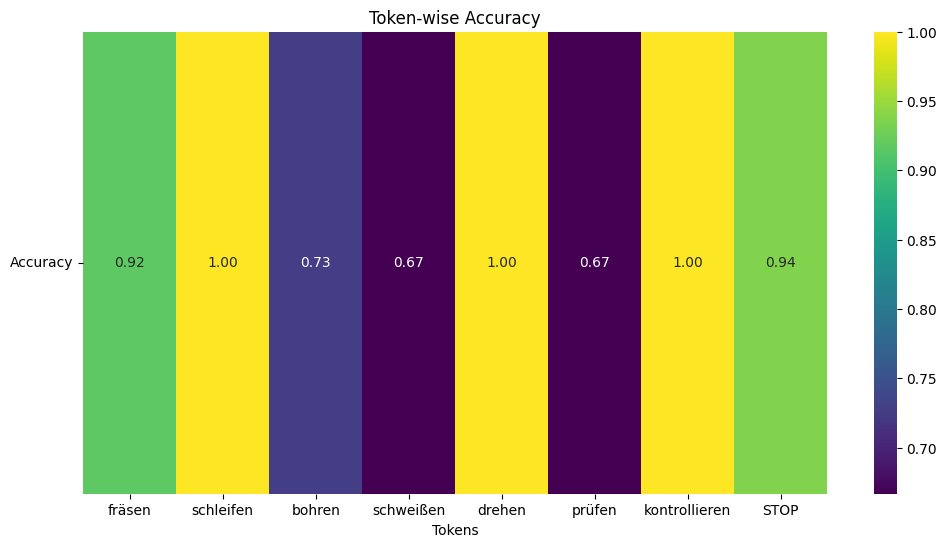


### Fehler Konfusionsmatrix ###


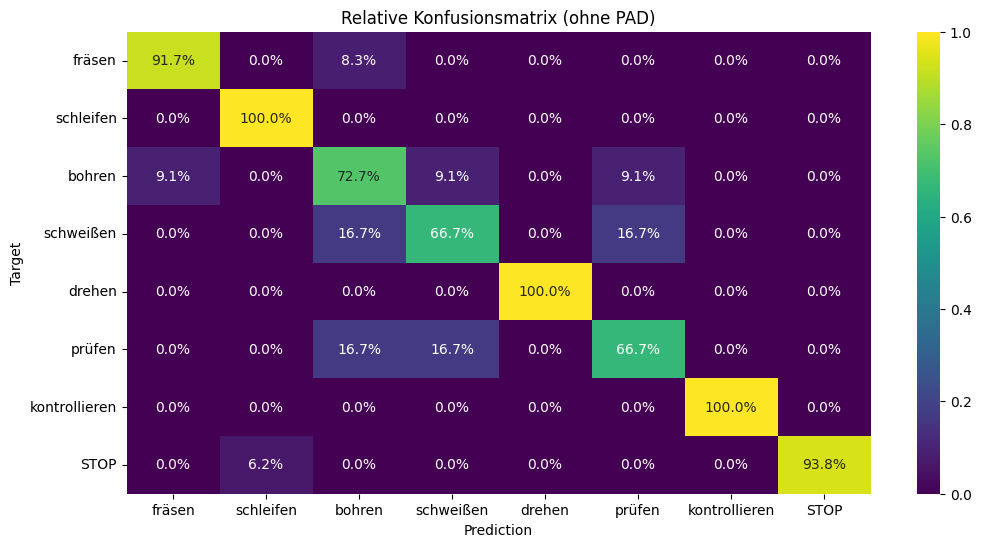

In [15]:
# init dir for experiment plot
SC = SequenceComparator(vocab=VOCAB, max_shift=3)
report_path = PATHS.REPORT_FIGURES / checkpoint_path.stem
report_path.mkdir(parents=True, exist_ok=True) 

SC.summary(padded_generated_sequences, seq.to(device), img_path=report_path.as_posix())